In [2]:
import boto3
import json
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Connect to S3
s3 = boto3.client('s3', region_name='us-east-2')
BUCKET = 'miami-weather-pipeline-juan'

# List all files in the bucket
response = s3.list_objects_v2(Bucket=BUCKET)
for obj in response.get('Contents', []):
    print(obj['Key'])

crypto-prices/2026/04/30/17-48-55.json
crypto-prices/2026/05/01/17-42-26.json
crypto-prices/2026/05/02/18-33-31.json
crypto-prices/2026/05/03/01-08-24.json
crypto-prices/2026/05/03/01-18-06.json
miami-weather/2026/04/30/15-38-03.json
miami-weather/2026/04/30/16-36-38.json
miami-weather/2026/05/01/17-42-04.json
miami-weather/2026/05/03/01-18-01.json
stock-prices/2026/05/01/17-09-04.json
stock-prices/2026/05/01/17-44-05.json
stock-prices/2026/05/02/16-52-49.json
stock-prices/2026/05/02/18-35-36.json
stock-prices/2026/05/03/01-09-51.json
stock-prices/2026/05/03/01-19-15.json


In [3]:
# Load all crypto data from S3
crypto_records = []

response = s3.list_objects_v2(Bucket=BUCKET, Prefix='crypto-prices/')
for obj in response.get('Contents', []):
    key = obj['Key']
    if key.endswith('.json'):
        file = s3.get_object(Bucket=BUCKET, Key=key)
        data = json.loads(file['Body'].read())
        timestamp = data['timestamp']
        for coin, values in data['prices'].items():
            values['coin'] = coin
            values['timestamp'] = timestamp
            crypto_records.append(values)

crypto_df = pd.DataFrame(crypto_records)
crypto_df['timestamp'] = pd.to_datetime(crypto_df['timestamp'])
crypto_df = crypto_df.sort_values('timestamp')
print(crypto_df[['timestamp','coin','price_usd','change_24h_percent']].to_string())

                    timestamp      coin  price_usd  change_24h_percent
0  2026-04-30 17:48:55.235928   bitcoin   76169.00                0.24
1  2026-04-30 17:48:55.235928  ethereum    2255.76               -0.82
2  2026-04-30 17:48:55.235928    solana      82.99               -0.01
3  2026-05-01 17:42:26.595485   bitcoin   78500.00                3.14
4  2026-05-01 17:42:26.595485  ethereum    2309.62                2.46
5  2026-05-01 17:42:26.595485    solana      84.16                1.47
6  2026-05-02 18:33:31.392027   bitcoin   78389.00               -0.15
7  2026-05-02 18:33:31.392027  ethereum    2309.12                0.10
8  2026-05-02 18:33:31.392027    solana      84.11                0.00
9  2026-05-03 01:08:24.639909   bitcoin   78363.00                0.05
10 2026-05-03 01:08:24.639909  ethereum    2309.22                0.55
11 2026-05-03 01:08:24.639909    solana      83.98                0.16
12 2026-05-03 01:18:06.848001   bitcoin   78352.00                0.07
13 202

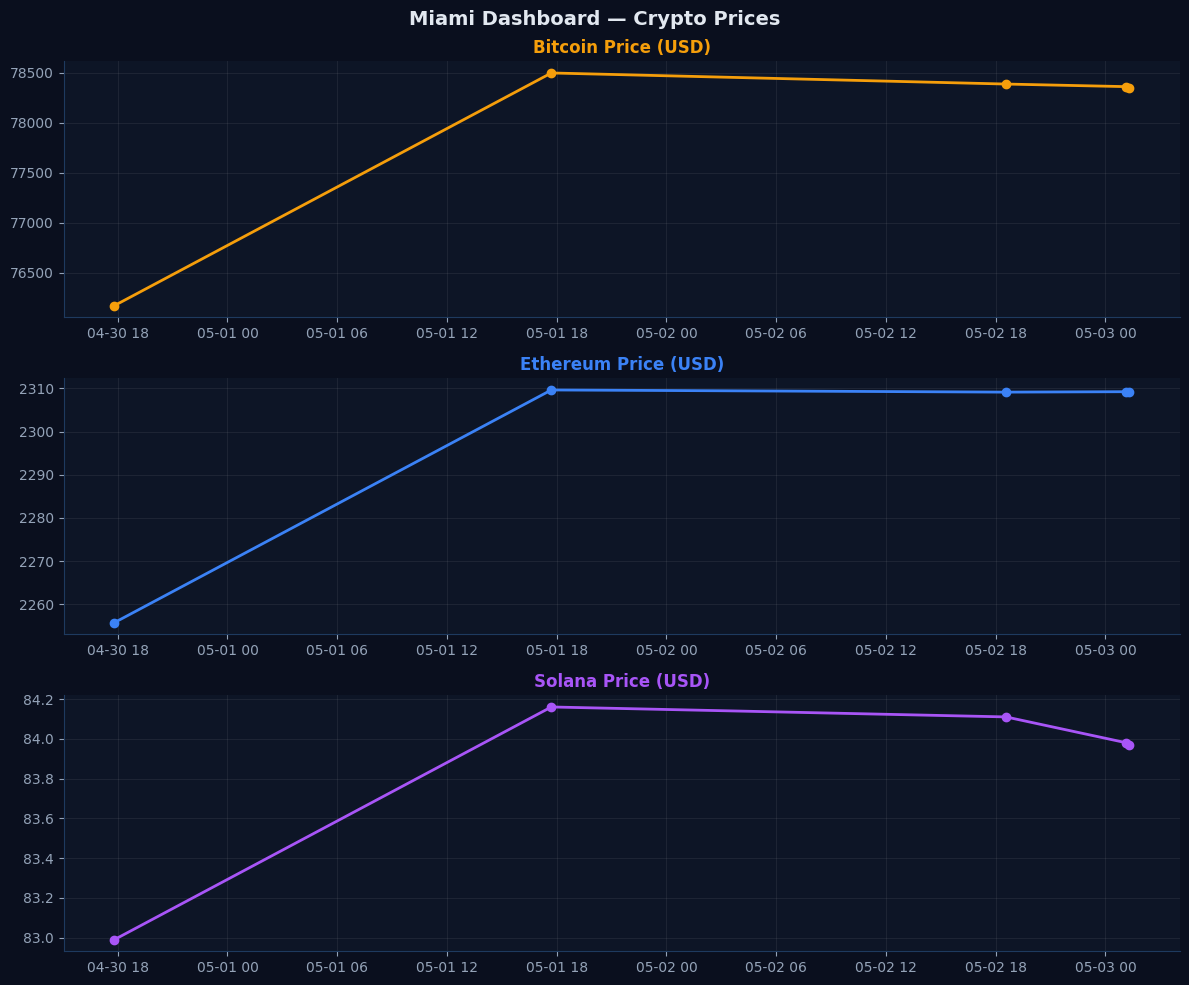

Chart saved!


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
coins = ['bitcoin', 'ethereum', 'solana']
colors = ['#f59e0b', '#3b82f6', '#a855f7']

for i, (coin, color) in enumerate(zip(coins, colors)):
    df = crypto_df[crypto_df['coin'] == coin]
    axes[i].plot(df['timestamp'], df['price_usd'], color=color, marker='o', linewidth=2)
    axes[i].set_title(f'{coin.capitalize()} Price (USD)', color=color, fontweight='bold')
    axes[i].set_facecolor('#0d1526')
    axes[i].tick_params(colors='#94a3b8')
    axes[i].yaxis.label.set_color('#94a3b8')
    axes[i].spines['bottom'].set_color('#1e3a5f')
    axes[i].spines['left'].set_color('#1e3a5f')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].grid(True, alpha=0.1)

fig.patch.set_facecolor('#0a0f1e')
plt.suptitle('Miami Dashboard — Crypto Prices', color='#e2e8f0', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('crypto_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

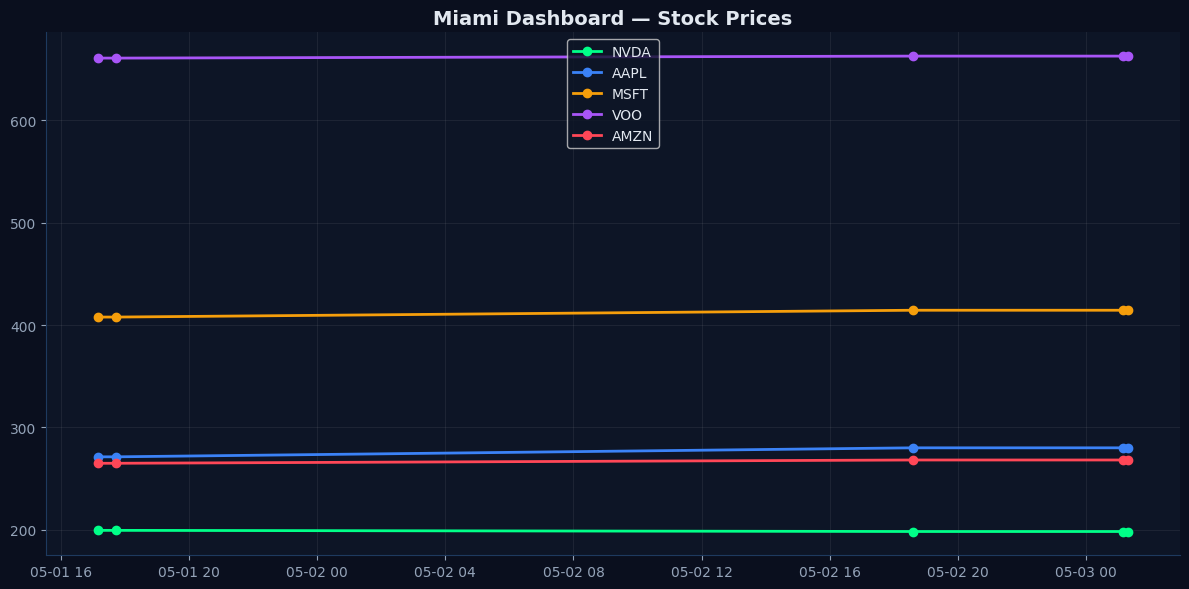

Chart saved!


In [5]:
# Load all stock data from S3
stock_records = []

response = s3.list_objects_v2(Bucket=BUCKET, Prefix='stock-prices/')
for obj in response.get('Contents', []):
    key = obj['Key']
    if key.endswith('.json'):
        file = s3.get_object(Bucket=BUCKET, Key=key)
        data = json.loads(file['Body'].read())
        timestamp = data['timestamp']
        for sym, values in data['stocks'].items():
            values['symbol'] = sym
            values['timestamp'] = timestamp
            stock_records.append(values)

stock_df = pd.DataFrame(stock_records)
stock_df['timestamp'] = pd.to_datetime(stock_df['timestamp'])
stock_df = stock_df.sort_values('timestamp')

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
symbols = ['NVDA', 'AAPL', 'MSFT', 'VOO', 'AMZN']
colors = ['#00ff88', '#3b82f6', '#f59e0b', '#a855f7', '#ff4757']

for sym, color in zip(symbols, colors):
    df = stock_df[stock_df['symbol'] == sym]
    ax.plot(df['timestamp'], df['price_usd'], color=color, marker='o', linewidth=2, label=sym)

ax.set_facecolor('#0d1526')
ax.tick_params(colors='#94a3b8')
ax.spines['bottom'].set_color('#1e3a5f')
ax.spines['left'].set_color('#1e3a5f')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.1)
ax.legend(facecolor='#0d1526', labelcolor='#e2e8f0')
fig.patch.set_facecolor('#0a0f1e')
plt.title('Miami Dashboard — Stock Prices', color='#e2e8f0', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('stock_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

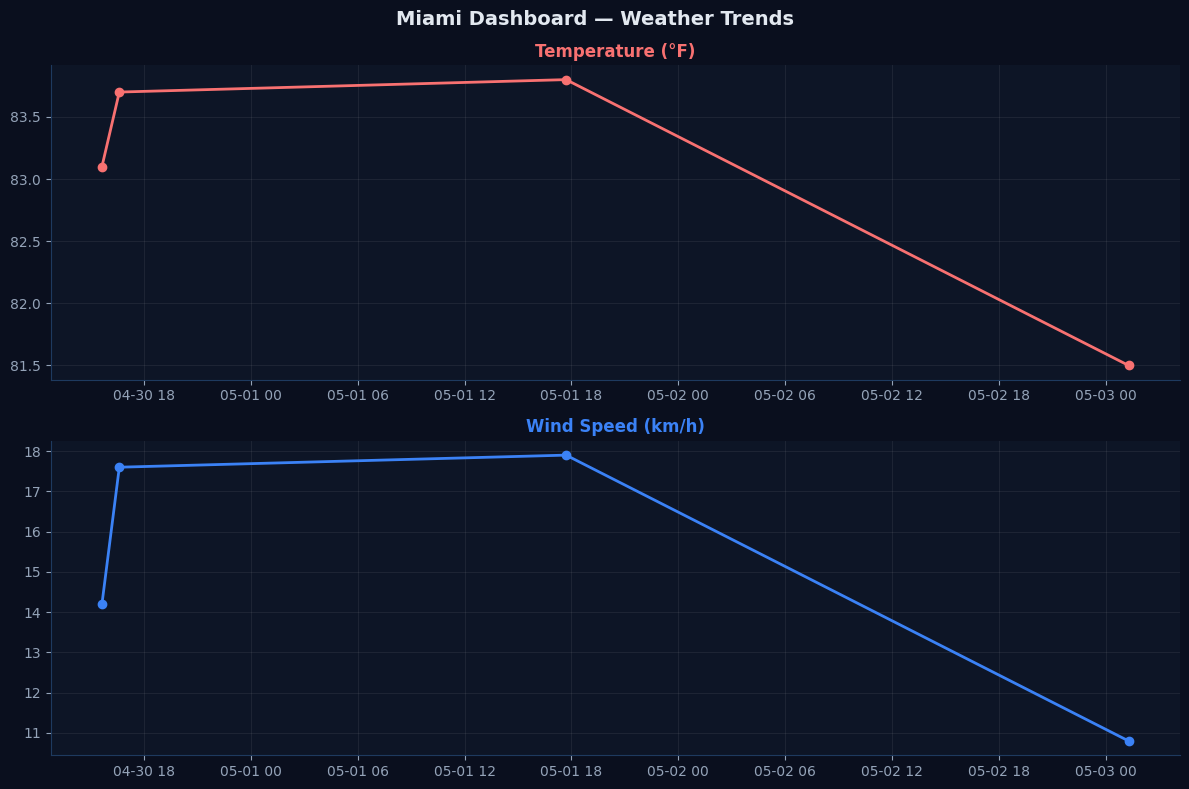

Chart saved!


In [6]:
# Load all weather data from S3
weather_records = []

response = s3.list_objects_v2(Bucket=BUCKET, Prefix='miami-weather/')
for obj in response.get('Contents', []):
    key = obj['Key']
    if key.endswith('.json'):
        file = s3.get_object(Bucket=BUCKET, Key=key)
        data = json.loads(file['Body'].read())
        weather_records.append({
            'timestamp': data['timestamp'],
            'temp_f': data['temperature_fahrenheit'],
            'humidity': data.get('relative_humidity') or data.get('humidity'),
            'wind_kmh': data['wind_speed_kmh'],
            'condition': data.get('condition', '')
        })

weather_df = pd.DataFrame(weather_records)
weather_df['timestamp'] = pd.to_datetime(weather_df['timestamp'])
weather_df = weather_df.sort_values('timestamp')

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(weather_df['timestamp'], weather_df['temp_f'], color='#f87171', marker='o', linewidth=2)
axes[0].set_title('Temperature (°F)', color='#f87171', fontweight='bold')
axes[0].set_facecolor('#0d1526')
axes[0].tick_params(colors='#94a3b8')
axes[0].spines['bottom'].set_color('#1e3a5f')
axes[0].spines['left'].set_color('#1e3a5f')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(True, alpha=0.1)

axes[1].plot(weather_df['timestamp'], weather_df['wind_kmh'], color='#3b82f6', marker='o', linewidth=2)
axes[1].set_title('Wind Speed (km/h)', color='#3b82f6', fontweight='bold')
axes[1].set_facecolor('#0d1526')
axes[1].tick_params(colors='#94a3b8')
axes[1].spines['bottom'].set_color('#1e3a5f')
axes[1].spines['left'].set_color('#1e3a5f')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(True, alpha=0.1)

fig.patch.set_facecolor('#0a0f1e')
plt.suptitle('Miami Dashboard — Weather Trends', color='#e2e8f0', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('weather_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")